# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 13: IMPROVED AUDIO CNN ON EXPANDED 8-GENRE PILOT
# ============================================================
# Purpose:
# This notebook retrains the improved audio CNN using the
# expanded 8-genre pilot subset derived from FMA-Large.
#
# The goal is to:
# 1. Load the expanded pilot metadata
# 2. Extract Mel spectrograms for the larger training set
# 3. Train the improved CNN architecture
# 4. Evaluate validation and test performance
# 5. Save CNN outputs for hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, regularizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

print("Seeds set to:", SEED)

Seeds set to: 42


In [2]:
# ============================================================
# 2. LOAD EXPANDED PILOT METADATA
# ============================================================

pilot_df = pd.read_csv("../data/processed/audio_large_pilot_metadata_expanded.csv")

print("Expanded pilot metadata shape:", pilot_df.shape)
display(pilot_df.head())

print("\nClass distribution:")
print(pilot_df["genre_top"].value_counts())

print("\nSplit distribution:")
print(pilot_df["split"].value_counts())

Expanded pilot metadata shape: (3137, 5)


,track_id,genre_top,split,audio_path,audio_exists
0,171,Rock,training,../data/raw/audio/fma_large\000\000171.mp3,True
1,178,Rock,training,../data/raw/audio/fma_large\000\000178.mp3,True
2,189,Folk,training,../data/raw/audio/fma_large\000\000189.mp3,True
3,191,Folk,training,../data/raw/audio/fma_large\000\000191.mp3,True
4,205,Folk,training,../data/raw/audio/fma_large\000\000205.mp3,True



Class distribution:
genre_top
Rock            400
Folk            400
Experimental    400
Hip-Hop         400
Electronic      400
Pop             400
Instrumental    400
Classical       337
Name: count, dtype: int64

Split distribution:
split
training      2400
test           375
validation     362
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. DEFINE MEL SPECTROGRAM FUNCTION
# ============================================================

def extract_mel_spectrogram(file_path, sr=22050, duration=30, n_mels=128, target_width=1292):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)

        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sample_rate,
            n_mels=n_mels
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        if mel_spec_db.shape[1] < target_width:
            pad_width = target_width - mel_spec_db.shape[1]
            mel_spec_db = np.pad(
                mel_spec_db,
                ((0, 0), (0, pad_width)),
                mode="constant"
            )
        else:
            mel_spec_db = mel_spec_db[:, :target_width]

        return mel_spec_db

    except Exception as e:
        print("Error processing:", file_path, e)
        return None

In [4]:
# ============================================================
# 4. BUILD AUDIO ARRAYS
# ============================================================

X_audio = []
y_audio = []
split_audio = []
track_ids_audio = []

for _, row in tqdm(pilot_df.iterrows(), total=len(pilot_df)):
    spec = extract_mel_spectrogram(row["audio_path"])

    if spec is not None:
        X_audio.append(spec)
        y_audio.append(row["genre_top"])
        split_audio.append(row["split"])
        track_ids_audio.append(row["track_id"])

X_audio = np.array(X_audio)
y_audio = np.array(y_audio)
split_audio = np.array(split_audio)
track_ids_audio = np.array(track_ids_audio)

print("X_audio shape:", X_audio.shape)
print("y_audio shape:", y_audio.shape)
print("split_audio shape:", split_audio.shape)

100%|██████████| 3137/3137 [06:22<00:00,  8.19it/s]


X_audio shape: (3137, 128, 1292)
y_audio shape: (3137,)
split_audio shape: (3137,)


In [5]:
# ============================================================
# 5. RESHAPE AND ENCODE LABELS
# ============================================================

X_audio = X_audio[..., np.newaxis]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_audio)

print("CNN input shape:", X_audio.shape)
print("Encoded classes:")
print(label_encoder.classes_)

CNN input shape: (3137, 128, 1292, 1)
Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [6]:
# ============================================================
# 6. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

X_train = X_audio[split_audio == "training"]
y_train = y_encoded[split_audio == "training"]

X_val = X_audio[split_audio == "validation"]
y_val = y_encoded[split_audio == "validation"]

X_test = X_audio[split_audio == "test"]
y_test = y_encoded[split_audio == "test"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2400, 128, 1292, 1) (2400,)
Validation: (362, 128, 1292, 1) (362,)
Test: (375, 128, 1292, 1) (375,)


In [7]:
# ============================================================
# 7. NORMALIZE INPUTS
# ============================================================

def safe_normalize(X):
    if X.size == 0:
        return X
    denom = np.max(np.abs(X))
    if denom == 0:
        return X
    return X / denom

X_train = safe_normalize(X_train)
X_val = safe_normalize(X_val)
X_test = safe_normalize(X_test)

print("Normalization complete.")

Normalization complete.


In [8]:
# ============================================================
# 8. COMPUTE CLASS WEIGHTS
# ============================================================

classes = np.unique(y_train)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


In [9]:
# ============================================================
# 9. BUILD IMPROVED CNN
# ============================================================

improved_cnn = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(label_encoder.classes_), activation="softmax")
])

improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 1292, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1292, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 646, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 646, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 646, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 323, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 323, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 323, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 161, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 161, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,440 (978.28 KB)

 Trainable params: 249,736 (975.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [10]:
# ============================================================
# 10. CALLBACKS
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [11]:
# ============================================================
# 11. TRAIN IMPROVED CNN
# ============================================================

history_improved = improved_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.3002 - loss: 1.9990 - val_accuracy: 0.1381 - val_loss: 3.3390 - learning_rate: 5.0000e-04
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.3652 - loss: 1.8066 - val_accuracy: 0.1989 - val_loss: 4.0627 - learning_rate: 5.0000e-04
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4163 - loss: 1.7162
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
150/150 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.4164 - loss: 1.7160 - val_accuracy: 0.1381 - val_loss: 4.1370 - learning_rate: 5.0000e-04
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.4749 - loss: 1.5763 - val_accuracy: 0.2624 - val_loss: 2.4499 - learning_rate: 2.5000e-04
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.4869 - loss: 1.5513 - val_accuracy: 0.3619 - val_loss: 1.8111 - learning_rate: 2.5000e-04
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 

In [12]:
# ============================================================
# 12. EVALUATE IMPROVED CNN
# ============================================================

improved_test_loss, improved_test_accuracy = improved_cnn.evaluate(X_test, y_test)

print("Improved CNN Test Accuracy:", improved_test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.3551 - loss: 1.7536
Improved CNN Test Accuracy: 0.41333332657814026


In [13]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

y_pred_probs_improved = improved_cnn.predict(X_test)
y_pred_improved = np.argmax(y_pred_probs_improved, axis=1)

print(classification_report(
    y_test,
    y_pred_improved,
    target_names=label_encoder.classes_,
    zero_division=0
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step
              precision    recall  f1-score   support

   Classical       0.67      0.16      0.26        25
  Electronic       0.57      0.32      0.41        50
Experimental       0.29      0.62      0.39        50
        Folk       0.37      0.28      0.32        50
     Hip-Hop       0.83      0.86      0.84        50
Instrumental       0.21      0.16      0.18        50
         Pop       0.21      0.12      0.15        50
        Rock       0.43      0.66      0.52        50

    accuracy                           0.41       375
   macro avg       0.45      0.40      0.38       375
weighted avg       0.43      0.41      0.39       375



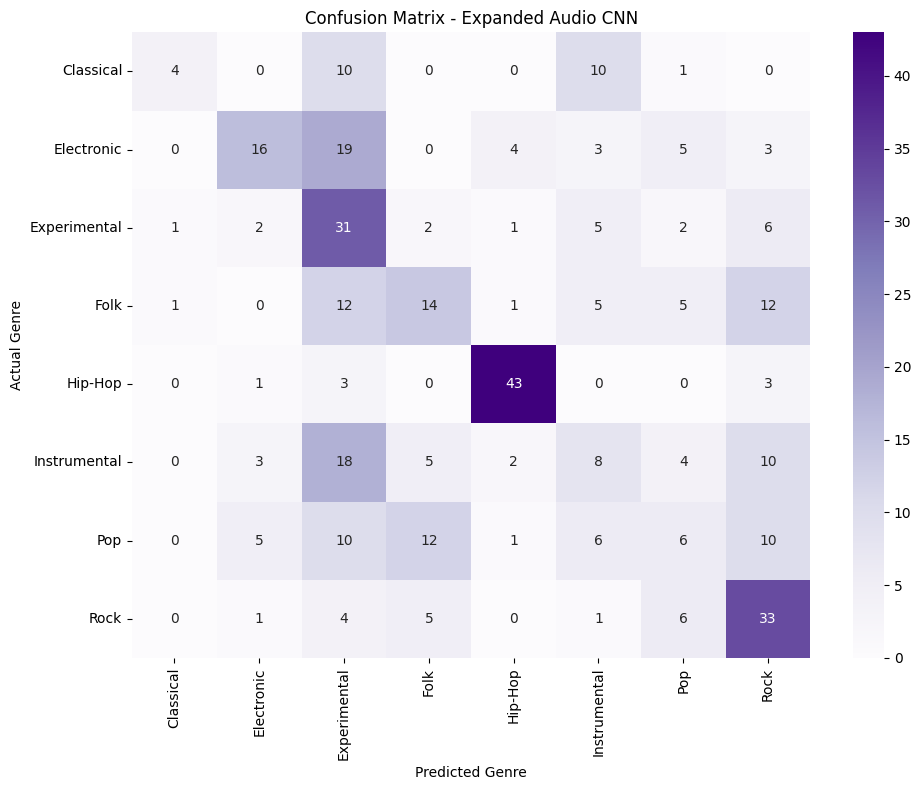

In [14]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Expanded Audio CNN")
plt.tight_layout()
plt.show()

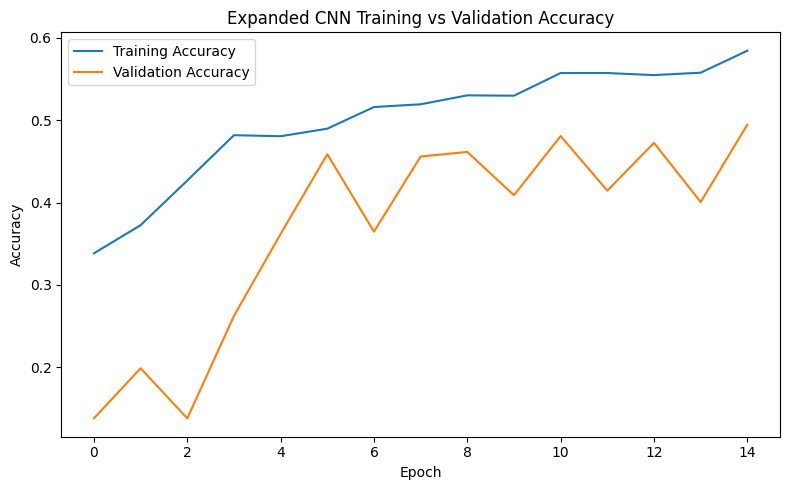

In [15]:
# ============================================================
# 15. TRAINING HISTORY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Expanded CNN Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 16. SAVE MODEL AND OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

improved_cnn.save("../models/improved_audio_cnn_expanded.keras")

val_probs_cnn = improved_cnn.predict(X_val)
test_probs_cnn = improved_cnn.predict(X_test)

np.save("../data/processed/val_probs_cnn_expanded.npy", val_probs_cnn)
np.save("../data/processed/test_probs_cnn_expanded.npy", test_probs_cnn)

np.save("../data/processed/y_val_cnn_expanded.npy", y_val)
np.save("../data/processed/y_test_cnn_expanded.npy", y_test)
np.save("../data/processed/cnn_label_classes_expanded.npy", label_encoder.classes_)

with open("../data/processed/improved_cnn_test_accuracy_expanded.txt", "w") as f:
    f.write(str(improved_test_accuracy))

print("Saved expanded CNN model and outputs.")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step
Saved expanded CNN model and outputs.


In [17]:
# ============================================================
# 17. INTERPRETATION NOTES
# ============================================================

print("1. This notebook retrains the improved audio CNN using a larger training set on the same 8 genres.")
print("2. Validation and test sets remain unchanged because Classical is the bottleneck class.")
print("3. The main expected gain comes from increased training examples.")
print("4. The saved outputs will be used later for expanded hybrid fusion.")

1. This notebook retrains the improved audio CNN using a larger training set on the same 8 genres.
2. Validation and test sets remain unchanged because Classical is the bottleneck class.
3. The main expected gain comes from increased training examples.
4. The saved outputs will be used later for expanded hybrid fusion.
